In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容
from extraction import find_一般政策语言_rule_base
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Heiti TC']  

/Users/ender_yang/opt/anaconda3/envs/lainchain/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_执行过程规定_rule_base(docs,一般政策性内容):
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # We need to standardize the 一般政策性内容 to avoid any characters at the beginning of the sentence
    一般政策性内容 = standerlize_一般政策性内容(一般政策性内容)
    
    # Define keywords for regular expression
    keywords =["(以|用|通过).*?(的方式|方法)","由.*?(主要负责|负责)","流程","程序","执行","分工","牵头","(?<!法律)(?<!公司)(?<!法人)(?<!社会)责任","措施","个阶段","进度"]
    pattern = re.compile('|'.join(keywords))
    
    paragraphs = pre_process(docs)
    matched_paragraphs = set()
    
    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        check_paragraph = re.sub(r'\s+', '', paragraph)
        if check_paragraph in 一般政策性内容:
            continue
        if pattern.search(paragraph):
            matched_paragraphs.add((paragraph.strip(), pattern.search(paragraph).group()))

    # Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index

## Demonstration for using find_执行过程规定_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[15]
docs = open(f'sample/{file_sample}', 'r').read()

$\textbf{Since we need 一般政策性内容 content, so we first extract 一般政策性内容}$

In [5]:
def get_一般政策语言(docs):
    matched_paragraphs_一般政策语言, _ = find_一般政策语言_rule_base(docs)
    一般政策语言_list = []
    for 一般政策语言, _ in matched_paragraphs_一般政策语言:
        一般政策语言_list += [一般政策语言]
        
    return 一般政策语言_list

In [6]:
# we can check the 一般政策语言 content
一般政策语言_list = get_一般政策语言(docs)
print(一般政策语言_list)

['《贵阳市蔬菜基地建设保护办法》(以下简称《办法》)修订工作已列入市人大地方性法规修订2016年度计划中，根据《修订工作实施方案》安排，近期市人大农经委、市法制局、市农委将组织召开《办法》修订讨论会，会议将汇总各方面对现执行的《办法》存在的问题的意见，梳理《办法》修订建议，保证修订后的《办法》的科学性、指导性、实用性、前瞻性，现将会议有关事宜通知如下：\u3000\u3000一、会议时间：']


## Now we can call the function find_执行过程规定_rule_base() ##

In [7]:
matched_paragraphs, matched_paragraphs_index = find_执行过程规定_rule_base(docs, 一般政策语言_list)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [8]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason
0,提供书面汇报材料（电子档）：各地根据蔬菜产业发展现状及规划，整理现行《办法》存在的问题和修订意见，重点体现（1）《办法》中关于立法目标、基地面积、建设标准、保护措施等方面存在的问题及修订建议；（2）《办法》关于执法部门及其责任的规定合理性存在的问题及修订建议；（3）《办法》中的规定缺乏应有的可操作性的问题及修订建议；（4）新菜地开发建设基金征收工作的问题及建议,措施


$\textbf{We can also check where is the sentence}$

In [9]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.2014615
原文链接：https://www.pkulaw.com/lar/df1c60f08f78ba532dd5080fdf976011bdfb.html
贵阳市农业委员会办公室关于召开《贵阳市蔬菜基地建设保护办法》修订讨论会的通知
贵阳市农业委员会办公室关于召开《贵阳市蔬菜基地建设保护办法》修订讨论会的通知
筑农办通字[2016]14号
各区（市、县）农业（水）局（蔬菜办）、双龙临空经济区农业部门：
　　《贵阳市蔬菜基地建设保护办法》(以下简称《办法》)修订工作已列入市人大地方性法规修订2016年度计划中，根据《修订工作实施方案》安排，近期市人大农经委、市法制局、市农委将组织召开《办法》修订讨论会，会议将汇总各方面对现执行的《办法》存在的问题的意见，梳理《办法》修订建议，保证修订后的《办法》的科学性、指导性、实用性、前瞻性，现将会议有关事宜通知如下：　　一、会议时间：
　　2016年1月26日（星期二）上午9：30
　　二、会议地点
　　市农委第二会议室
　　三、参会人员
　　各区（市、县、双龙临空经济区）农业行政主管部门分管蔬菜基地建设的领导；蔬菜龙头企业（合作社）代表。
　　四、参会要求
　　提供书面汇报材料（电子档）：各地根据蔬菜产业发展现状及规划，整理现行《办法》存在的问题和修订意见，重点体现（1）《办法》中关于立法目标、基地面积、建设标准、保护措施等方面存在的问题及修订建议；（2）《办法》关于执法部门及其责任的规定合理性存在的问题及修订建议；（3）《办法》中的规定缺乏应有的可操作性的问题及修订建议；（4）新菜地开发建设基金征收工作的问题及建议。
贵阳市农业委员会办公室
2016年1月19日



## Now we can run batch processing on our sample data ##

In [10]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['filename', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length', '一般政策语言'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        一般政策语言_list = get_一般政策语言(docs)
        
        matched_paragraphs, matched_paragraphs_index = find_执行过程规定_rule_base(docs, 一般政策语言_list)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list), "\n".join(一般政策语言_list)]
    
    return return_df


In [11]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,filename,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言
0,佛山市人力资源和社会保障局关于新增血友病(...(FBM-CLI.12.6305146).txt,,,558,0,为进一步提高我市城镇职工基本医疗保险参保人员血友病门诊特定病种医疗保险待遇，根据《佛山市城镇职工基本医疗保险门诊特定病种管理暂行办法》（佛劳社〔2007〕1108号）和《进一步完善城镇职工基本医疗保险有关问题的意见》（佛劳社[2009]143号）的有关规定，现将我市城镇职工基本医疗保险部分门诊特定病种规定如下：
1,吉林省工业和信息化厅关于转发《工业和信息化...(FBM-CLI.12.1054681).txt,各地要把示范基地创建工作真正纳入到工业和信息化重点工作中，明确责任分工，理顺工作机制\n各地要深刻领会《指导意见》精神，突出发展重点，研究制定切实可行的推动示范基地加快发展的政策措施\n《指导意见》提出了示范基地创建工作的总体要求、主要任务、主要措施和保障机制,责任\n措施\n措施,1088,128,为了进一步推动我省示范基地的创建工作，加强对示范基地的培育、扶持和服务，现将《指导意见》转发给你们，请你们结合实际，贯彻落实好《指导意见》，为此，提出以下几点要求：
2,北京市公安局关于印发户籍派出所设立公共户工...(FBM-CLI.12.4083221).txt,4.申请人应确保提供的证件材料真实准确，对于申请材料弄虚作假的，公安机关将取消其申请迁移事项；构成违法犯罪的，依法追究行政刑事责任\n（二）办理流程及时限\n（三）申请人应确保提供的证件材料真实准确，对于申请材料弄虚作假的，公安机关将取消其申请迁移事项；构成违法犯罪的，依法追究行政刑事责任\n三、“公共户”迁移办理程序\n本规定自2021年6月1日起执行\n2.房屋所有权人或公有住房承租人申请将本房滞留户口人员迁入“公共户”办理流程及时限\n涉及其他户口办理事项，按照现有政策执行\n1.申请人或监护人申请迁入“公共户”办理流程及时限\n4.新生儿在“公共户”申报出生登记的，按本市新生儿申报出生登记工作流程办理\n3.“公共户”户内人员迁出“公共户”办理流程及时限,责任\n流程\n责任\n程序\n执行\n流程\n执行\n流程\n流程\n流程,4274,326,为有效解决暂不具备市内迁移条件的本市户籍人员落户问题，经第5次市局局长办公会通过，现将《北京市公安局户籍派出所设立公共户工作规定（试行）》印发给你们，请认真贯彻执行
3,淄博市文化和旅游局对市政协十二届五次会议委...(FBM-CLI.12.5629955).txt,"通过此项目将全面构建“1+3+X""新型智慧文旅数字化体系，即1个主题库“文化和旅游主题库""；3个融合平台，“文化旅游监管平台""“文化旅游营销推广平台""和“文化旅游公众服务平台""；X项智慧文旅创新应用，包含“新整合的统一文化旅游门户""、全面升级的“淄博数字文旅移动端应用体系（含公众号、小程序或爱淄博APP接入等）""、“领导驾驶舱""“数字文化馆""“文化遗产数字化管理系统""“5G慢直播""“AR数字旅游计划""“智慧景区导览""",程序,1298,210,贵单位提出的关于进一步加快数字文旅整合发展的建议收悉，现答复如下：
4,广西壮族自治区文化和旅游厅办公室关于印发《...(FBM-CLI.12.3014292).txt,,,613,0,为进一步提高广西特色旅游名县创建工作的科学性、针对性和可操作性，促进文化和旅游融合发展，我厅对《广西特色旅游名县创建工作管理办法》和《广西特色旅游名县评定标准与评分细则》进行了修订


In [12]:
# We can check if the Retrieve Info is in 一般政策语言
for index, row in df.iterrows():
    if row['Retrieve Info'] == '':
        continue
    
    Retrieve_Info = row['Retrieve Info'].split('\n')
    一般政策语言 = row['一般政策语言'].split('\n')
    
    for info in Retrieve_Info:
        if info in 一般政策语言:
            print(info)

$\textbf{Here we provide some statistics on the results}$

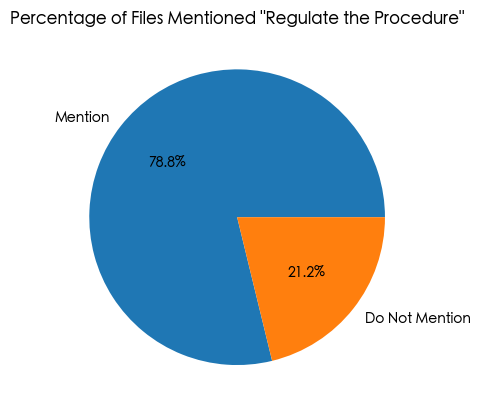

In [13]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "Regulate the Procedure"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

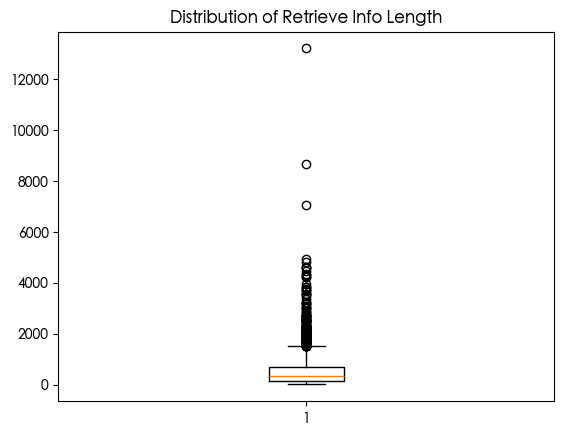

In [14]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

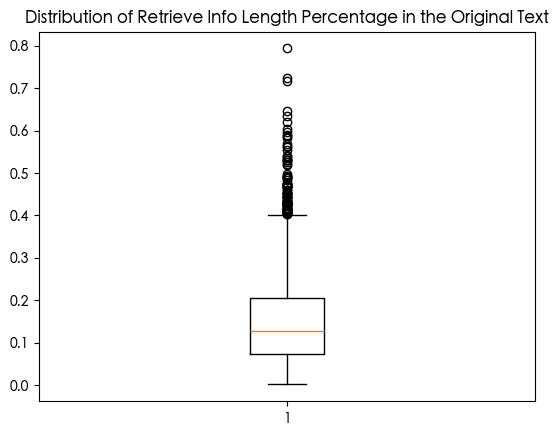

In [15]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [16]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

filename  \
1777  河北省住房和城乡建设厅关于印发《建筑施工安...(FBM-CLI.12.1280747).txt   
2942  中共银川市委办公厅、银川市人民政府办公厅印...(FBM-CLI.12.1405377).txt   
1239  烟台市海洋与渔业局关于印发《烟台市海洋与渔...(FBM-CLI.12.1788258).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [17]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

filename  \
71    广西壮族自治区新型冠状病毒感染的肺炎疫情防...(FBM-CLI.12.1566879).txt   
2942  中共银川市委办公厅、银川市人民政府办公厅印...(FBM-CLI.12.1405377).txt   
1226  南京市食品安全委员会办公室关于进一步推进全...(FBM-CLI.12.2478541).txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

## We can also comparing the statistics results between different labels in our sample by aggrigate the labels from task B ##

In [18]:
df_label = pd.read_csv('policies_label.csv')
df_all = df.join(on='filename', how = 'inner', other = df_label.set_index('filename'))

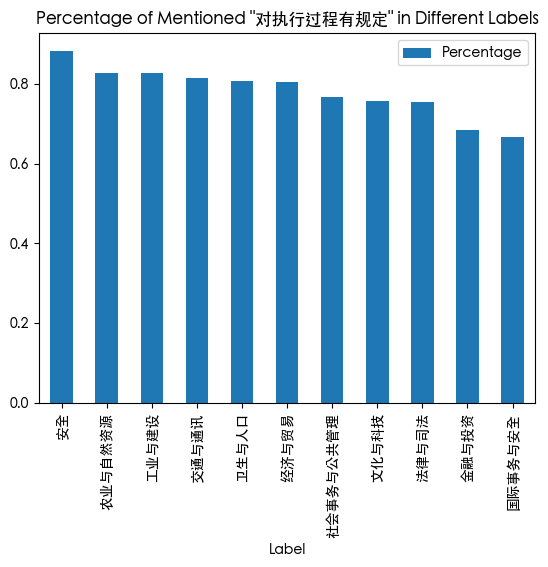

In [19]:
# we use l1 to aggregate the result
agg_result = etrieve_info_length = df_all.groupby('label_L1')

data = []
for name, group in agg_result:
    total = group['Retrieve Info Length'].count()
    mention = group[group['Retrieve Info Length'] != 0]['Retrieve Info Length'].count()
    data.append((name, mention, total, mention/total))

data.sort(key=lambda x: x[3], reverse=True)

# plot the result so we can see the percentage of the mention in different labels
df_plot = pd.DataFrame(data, columns=['Label', 'Mention', 'Total', 'Percentage'])
df_plot.plot(x='Label', y='Percentage', kind='bar')
plt.title('Percentage of Mentioned "对执行过程有规定" in Different Labels')
plt.xticks(rotation=90)
plt.show()

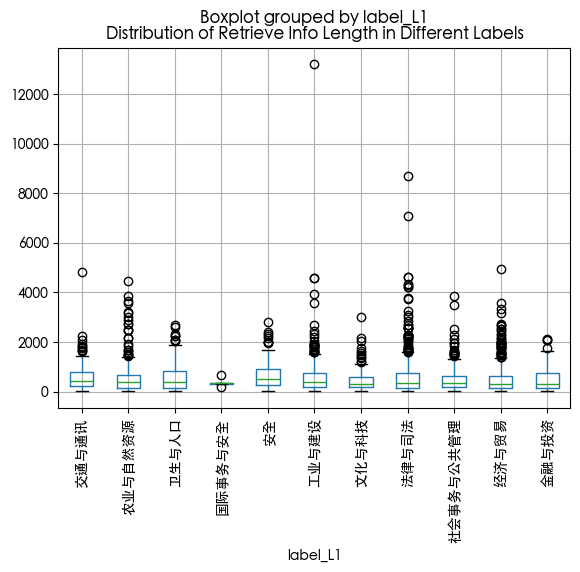

In [20]:
# we can also plot box plot to show the distribution of retrieve info length in different labels
df_temp = df_all.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
df_temp.boxplot(column='Retrieve Info Length', by='label_L1')
plt.title('Distribution of Retrieve Info Length in Different Labels')
plt.xticks(rotation=90)
plt.show()

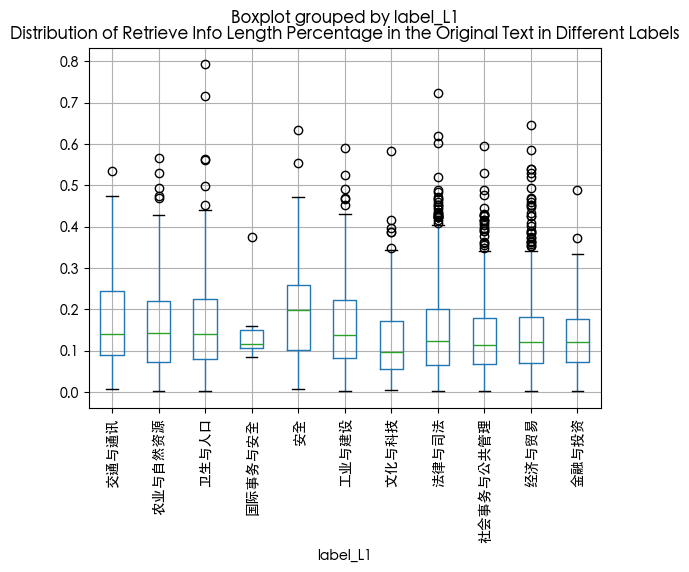

In [21]:
# we can also show the distribution that to what percentage of the document is the retrieve info in different labels
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
df_temp.boxplot(column='Retrieve Info Length Percentage', by='label_L1')
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text in Different Labels')
plt.xticks(rotation=90)
plt.show()